# Person 2 — Model Building, Comparison & Hyperparameter Tuning
### FairCredit · Loan Eligibility Checker

## Cell 1 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os, warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, auc,
                             ConfusionMatrixDisplay, confusion_matrix)
from sklearn.model_selection import RandomizedSearchCV

print("All imports OK")

All imports OK


## Cell 2 — Load Processed Data

In [6]:
# ── Update these paths to match your folder structure ──────────────────────
DATA_DIR   = "../dataset/data processed"          # adjust if needed
MODELS_DIR = "../models"
REPORTS_DIR= "../reports"

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

print("Shapes:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_test : {X_test.shape}   y_test : {y_test.shape}")
assert X_train.shape[0] == y_train.shape[0], "Row mismatch in train set!"
assert X_test.shape[0]  == y_test.shape[0],  "Row mismatch in test set!"
print("Sanity check passed.")

Shapes:
  X_train: (96658, 11)  y_train: (96658,)
  X_test : (24165, 11)   y_test : (24165,)
Sanity check passed.


## Cell 3 — Metrics Helper & Class Imbalance

In [9]:
def get_metrics(name, y_true, y_pred, y_prob):
    """Return a dict of 5 standard classification metrics."""
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred),        4),
        "Precision": round(precision_score(y_true, y_pred,
                           zero_division=0),                       4),
        "Recall"   : round(recall_score(y_true, y_pred,
                           zero_division=0),                       4),
        "F1-Score" : round(f1_score(y_true, y_pred,
                           zero_division=0),                       4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_prob),         4),
    }

results = []   # will hold one dict per model — do NOT reset this later

# Class imbalance ratio (used by XGBoost)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Class split — Negative (0): {neg}  Positive (1): {pos}")
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

Class split — Negative (0): 89944  Positive (1): 6714
scale_pos_weight = 13.396


## Cell 4 — Logistic Regression (Baseline)

In [12]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

lr_metrics = get_metrics("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
results.append(lr_metrics)

print("--- Logistic Regression ---")
for k, v in lr_metrics.items():
    if k != "Model":
        print(f"  {k:<12}: {float(v):.4f}")

--- Logistic Regression ---
  Accuracy    : 0.7958
  Precision   : 0.2188
  Recall      : 0.7540
  F1-Score    : 0.3391
  ROC-AUC     : 0.8548


## Cell 5 — Random Forest

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

rf_metrics = get_metrics("Random Forest", y_test, y_pred_rf, y_prob_rf)
results.append(rf_metrics)

print("--- Random Forest ---")
for k, v in rf_metrics.items():
    if k != "Model":
        print(f"  {k:<12}: {float(v):.4f}")

# Top-5 feature importances
feat_imp = pd.Series(rf.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)
print("Top 5 features (RF):")
print(feat_imp.head(5).to_string())

--- Random Forest ---
  Accuracy    : 0.9311
  Precision   : 0.5142
  Recall      : 0.1400
  F1-Score    : 0.2200
  ROC-AUC     : 0.8238
Top 5 features (RF):
RevolvingUtilizationOfUnsecuredLines    0.218850
DebtRatio                               0.142015
TotalPastDue                            0.131278
MonthlyIncome                           0.130538
age                                     0.114066


## Cell 6 — XGBoost Baseline

In [19]:
xgb_base = XGBClassifier(
    eval_metric       = "logloss",
    scale_pos_weight  = scale_pos_weight,
    random_state      = 42,
    verbosity         = 0,
)
xgb_base.fit(X_train, y_train)

y_pred_xgb_base = xgb_base.predict(X_test)
y_prob_xgb_base = xgb_base.predict_proba(X_test)[:, 1]

xgb_base_metrics = get_metrics("XGBoost (baseline)", y_test,
                                y_pred_xgb_base, y_prob_xgb_base)
results.append(xgb_base_metrics)

print("--- XGBoost Baseline ---")
for k, v in xgb_base_metrics.items():
    if k != "Model":
        print(f"  {k:<12}: {float(v):.4f}")

--- XGBoost Baseline ---
  Accuracy    : 0.8261
  Precision   : 0.2410
  Recall      : 0.6992
  F1-Score    : 0.3585
  ROC-AUC     : 0.8440


## Cell 7 — Model Comparison Table & ROC Curves
*(baseline only — tuned XGBoost added in Cell 10)*

===== Baseline Model Comparison =====
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7958     0.2188  0.7540    0.3391   0.8548
Random Forest          0.9311     0.5142  0.1400    0.2200   0.8238
XGBoost (baseline)     0.8261     0.2410  0.6992    0.3585   0.8440
Saved → reports/model_comparison.csv


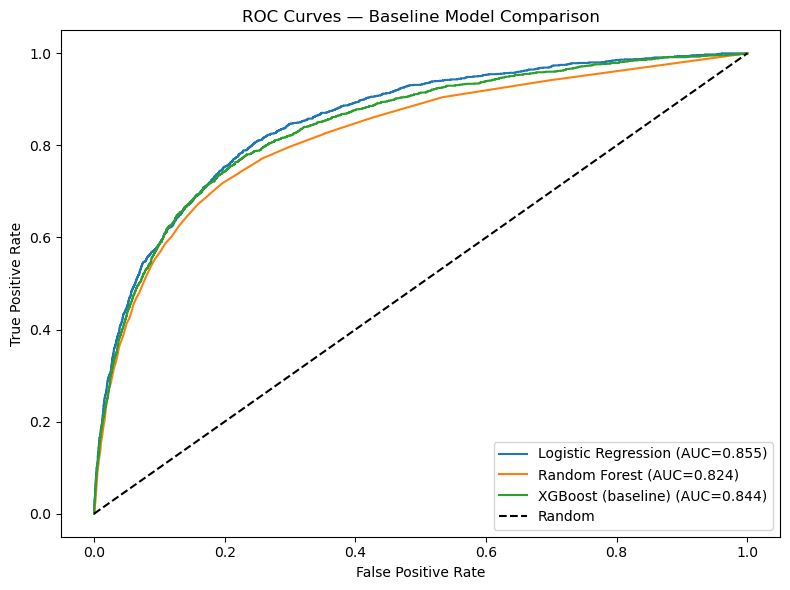

Saved → reports/roc_curves.png


In [22]:
results_df = pd.DataFrame(results).set_index("Model")
print("===== Baseline Model Comparison =====")
print(results_df.to_string())
results_df.to_csv(f"{REPORTS_DIR}/model_comparison.csv")
print("Saved → reports/model_comparison.csv")

# ROC curves
plt.figure(figsize=(8, 6))
for name, y_prob in [("Logistic Regression", y_prob_lr),
                     ("Random Forest",       y_prob_rf),
                     ("XGBoost (baseline)",  y_prob_xgb_base)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Baseline Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/roc_curves.png", dpi=150)
plt.show()
print("Saved → reports/roc_curves.png")

## Cell 8 — XGBoost Confusion Matrix

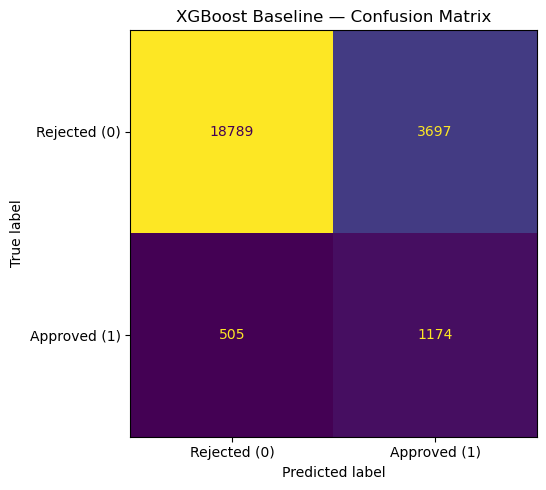

Saved → reports/xgb_confusion_matrix.png
True  Positives (correctly approved) : 1174
True  Negatives (correctly rejected)  : 18789
False Positives (wrongly approved)    : 3697  ← fairness risk
False Negatives (wrongly rejected)    : 505  ← fairness risk


In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_base, ax=ax,
    display_labels=["Rejected (0)", "Approved (1)"],
    colorbar=False
)
ax.set_title("XGBoost Baseline — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/xgb_confusion_matrix.png", dpi=150)
plt.show()
print("Saved → reports/xgb_confusion_matrix.png")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb_base).ravel()
print(f"True  Positives (correctly approved) : {tp}")
print(f"True  Negatives (correctly rejected)  : {tn}")
print(f"False Positives (wrongly approved)    : {fp}  ← fairness risk")
print(f"False Negatives (wrongly rejected)    : {fn}  ← fairness risk")

## Cell 9 — Hyperparameter Tuning with RandomizedSearchCV

**Fixes applied vs original code:**
| Issue | Original | Fixed |
|---|---|---|
|  | 10 (explored only 14% of space) | **30** (as per workflow spec) |
|  | 3-fold | **5-fold** (more stable estimates) |
|  range | [100, 200] | **[100, 200, 300]** |
|  range | [3, 4, 5] | **[3, 4, 5, 6]** |
|  range | [0.05, 0.1, 0.2] | **[0.01, 0.05, 0.1, 0.2]** (0.01 often best) |
|  range | [0.8, 1.0] | **[0.7, 0.8, 1.0]** |
|  range | [0.8, 1.0] | **[0.7, 0.8, 1.0]** |
|  | 1 | **-1** (use all cores — safe now, not during exam) |

In [28]:
# ── Full param grid (matches workflow spec) ─────────────────────────────────
param_grid = {
    "n_estimators"   : [100, 200, 300],
    "max_depth"       : [3, 4, 5, 6],
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "subsample"       : [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
# 3×4×4×3×3 = 432 combinations — n_iter=30 samples ~7% (unbiased random sample)

xgb_tune = XGBClassifier(
    eval_metric      = "logloss",
    scale_pos_weight = scale_pos_weight,
    random_state     = 42,
    verbosity        = 0,
)

search = RandomizedSearchCV(
    xgb_tune,
    param_distributions = param_grid,
    scoring             = "roc_auc",   # optimise for AUC (imbalanced dataset)
    n_iter              = 30,           # as per workflow spec
    cv                  = 5,            # 5-fold as per workflow spec
    random_state        = 42,
    n_jobs              = -1,           # use all CPU cores
    verbose             = 1,
    refit               = True,         # refit best model on full train set
)
search.fit(X_train, y_train)

print("Best Parameters Found:")
for param, value in search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

best_xgb = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters Found:
  subsample           : 0.7
  n_estimators        : 200
  max_depth           : 3
  learning_rate       : 0.05
  colsample_bytree    : 0.7
Best CV ROC-AUC: 0.8563


## Cell 10 — Evaluate Tuned XGBoost & Update Comparison Table

In [31]:
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned  = best_xgb.predict_proba(X_test)[:, 1]

xgb_tuned_metrics = get_metrics("XGBoost (tuned)", y_test,
                                 y_pred_xgb_tuned, y_prob_xgb_tuned)

# ── FIX: append tuned results to the list (was missing in original) ──────────
results.append(xgb_tuned_metrics)

print("--- XGBoost (Tuned) Results ---")
for k, v in xgb_tuned_metrics.items():
    if k != "Model":
        print(f"  {k:<12}: {float(v):.4f}")

# ── Side-by-side comparison: baseline vs tuned ───────────────────────────────
print("===== Baseline vs Tuned XGBoost =====")
compare = pd.DataFrame([xgb_base_metrics, xgb_tuned_metrics]).set_index("Model")
print(compare.to_string())

delta = compare.loc["XGBoost (tuned)"] - compare.loc["XGBoost (baseline)"]
print("Delta (tuned − baseline):")
for metric, diff in delta.items():
    symbol = "+" if diff >= 0 else ""
    print(f"  {metric:<12}: {symbol}{float(diff):.4f}")

# ── Update and re-save the full comparison table ─────────────────────────────
all_results_df = pd.DataFrame(results).set_index("Model")
all_results_df.to_csv(f"{REPORTS_DIR}/model_comparison.csv")
print("Updated comparison saved → reports/model_comparison.csv")

--- XGBoost (Tuned) Results ---
  Accuracy    : 0.7889
  Precision   : 0.2197
  Recall      : 0.7987
  F1-Score    : 0.3446
  ROC-AUC     : 0.8642
===== Baseline vs Tuned XGBoost =====
                    Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                             
XGBoost (baseline)    0.8261     0.2410  0.6992    0.3585   0.8440
XGBoost (tuned)       0.7889     0.2197  0.7987    0.3446   0.8642
Delta (tuned − baseline):
  Accuracy    : -0.0372
  Precision   : -0.0213
  Recall      : +0.0995
  F1-Score    : -0.0139
  ROC-AUC     : +0.0202
Updated comparison saved → reports/model_comparison.csv


## Cell 11 — Updated ROC Curves (including Tuned XGBoost)

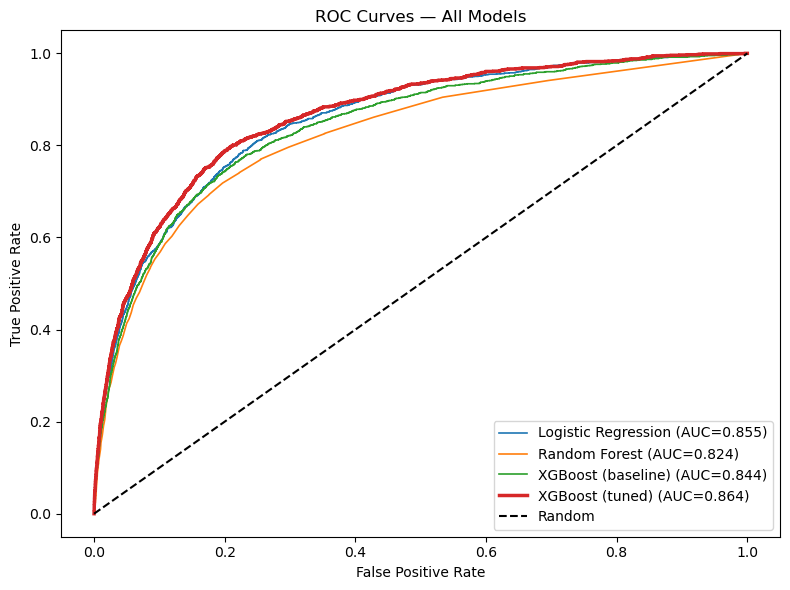

Saved → reports/roc_curves.png


In [34]:
plt.figure(figsize=(8, 6))
for name, y_prob in [("Logistic Regression",  y_prob_lr),
                     ("Random Forest",         y_prob_rf),
                     ("XGBoost (baseline)",    y_prob_xgb_base),
                     ("XGBoost (tuned)",       y_prob_xgb_tuned)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    lw = 2.5 if "tuned" in name else 1.2
    plt.plot(fpr, tpr, linewidth=lw, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/roc_curves.png", dpi=150)
plt.show()
print("Saved → reports/roc_curves.png")

## Cell 12 — Save Final Model & Best Params

In [39]:
# Save tuned model as xgb_baseline.pkl (handed to Person 3)
joblib.dump(best_xgb, f"{MODELS_DIR}/xgb_baseline.pkl")
print(f"Model saved → {MODELS_DIR}/xgb_baseline.pkl")

# Save best params as JSON
with open(f"{MODELS_DIR}/xgb_best_params.json", "w") as f:
    json.dump(search.best_params_, f, indent=2)
print(f"Best params saved → {MODELS_DIR}/xgb_best_params.json")

# Quick verification — reload and predict to confirm pkl is not corrupted
reloaded = joblib.load(f"{MODELS_DIR}/xgb_baseline.pkl")
verify_pred = reloaded.predict(X_test[:5])
print(f"Verification (first 5 test predictions): {verify_pred}")
print("Model reload OK — ready to hand off to Person 3.")

Model saved → ../models/xgb_baseline.pkl
Best params saved → ../models/xgb_best_params.json
Verification (first 5 test predictions): [0 0 0 0 0]
Model reload OK — ready to hand off to Person 3.


## Cell 13 — Outlier Capping (Winsorization)

**Why:** `MonthlyIncome` has a max of **1,794,060** but a 99th percentile of just **25,000** — a single extreme value that distorts StandardScaler for 96,000+ rows. `age` reaches 105 (biologically implausible). Capping at the 99th percentile removes this distortion without deleting any rows.

In [42]:
# Columns to cap at their 99th percentile
CAP_COLS = [
    "RevolvingUtilizationOfUnsecuredLines",
    "MonthlyIncome",
    "DebtRatio",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "age",
]

# Compute caps FROM TRAINING DATA ONLY (no data leakage)
caps = {col: X_train[col].quantile(0.99) for col in CAP_COLS}

def apply_caps(df, caps):
    df = df.copy()
    for col, cap in caps.items():
        df[col] = df[col].clip(upper=cap)
    return df

X_train_capped = apply_caps(X_train, caps)
X_test_capped  = apply_caps(X_test,  caps)   # use train-derived caps on test

print("Caps applied (99th percentile from training data):")
for col, cap in caps.items():
    before = X_train[col].max()
    after  = X_train_capped[col].max()
    print(f"  {col:<45} before max: {before:>12.1f}  after max: {after:>10.1f}")

Caps applied (99th percentile from training data):
  RevolvingUtilizationOfUnsecuredLines          before max:          4.4  after max:        1.1
  MonthlyIncome                                 before max:    1794060.0  after max:    25000.0
  DebtRatio                                     before max:          9.9  after max:        3.3
  NumberOfOpenCreditLinesAndLoans               before max:         58.0  after max:       25.0
  NumberRealEstateLoansOrLines                  before max:         54.0  after max:        5.0
  NumberOfDependents                            before max:         20.0  after max:        4.0
  age                                           before max:        105.0  after max:       86.4


## Cell 14 — Feature Engineering

**5 new domain-informed features** derived from the existing columns:

| Feature | Formula | Why it matters |
|---|---|---|
| `HasAnyLate` | `TotalPastDue > 0` | Binary flag — presence of any delinquency is a strong signal |
| `DebtToIncome` | `DebtRatio / (MonthlyIncome + 1)` | Classic credit risk ratio |
| `IncomePerDependent` | `MonthlyIncome / (Dependents + 1)` | Disposable income proxy |
| `UtilizationRisk` | `RevolvingUtilization × DebtRatio` | Combined financial stress score |
| `CreditMaturity` | `age / (OpenCreditLines + 1)` | Credit experience per open line |

In [45]:
def engineer_features(df):
    df = df.copy()

    # 1. Binary flag — any past delinquency at all
    df["HasAnyLate"] = (df["TotalPastDue"] > 0).astype(int)

    # 2. Debt burden relative to income
    df["DebtToIncome"] = df["DebtRatio"] / (df["MonthlyIncome"] + 1)

    # 3. Income available per dependent
    df["IncomePerDependent"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

    # 4. Combined utilization + debt stress
    df["UtilizationRisk"] = (df["RevolvingUtilizationOfUnsecuredLines"]
                             * df["DebtRatio"])

    # 5. Credit experience score
    df["CreditMaturity"] = df["age"] / (df["NumberOfOpenCreditLinesAndLoans"] + 1)

    return df

X_train_eng = engineer_features(X_train_capped)
X_test_eng  = engineer_features(X_test_capped)

new_features = ["HasAnyLate", "DebtToIncome", "IncomePerDependent",
                "UtilizationRisk", "CreditMaturity"]

print(f"Features before: {X_train.shape[1]}  →  after: {X_train_eng.shape[1]}")
print()
print("New feature stats:")
print(X_train_eng[new_features].describe().round(4).to_string())

Features before: 11  →  after: 16

New feature stats:
       HasAnyLate  DebtToIncome  IncomePerDependent  UtilizationRisk  CreditMaturity
count  96658.0000    96658.0000          96658.0000       96658.0000      96658.0000
mean       0.2079        0.0023           4418.0606           0.1353          7.4291
std        0.4058        0.0790           3499.0846           0.2503          6.5398
min        0.0000        0.0000              0.0000           0.0000          0.9615
25%        0.0000        0.0000           2019.3750           0.0040          3.9333
50%        0.0000        0.0000           3500.0000           0.0400          5.6000
75%        0.0000        0.0001           5601.0000           0.1699          8.4000
max        1.0000        3.3354          25000.0000           3.5456         86.4300


## Cell 15 — Log Transform Highly Skewed Features

Features with skewness > 3 distort distance-based models. XGBoost is tree-based so it's less sensitive, but log-transforming reduces the impact of extreme outliers and makes splits more meaningful.

In [48]:
import numpy as np

# Columns with skewness > 3 (computed earlier)
LOG_COLS = [
    "MonthlyIncome",
    "DebtRatio",
    "DebtToIncome",
    "IncomePerDependent",
]

def log_transform(df, cols):
    df = df.copy()
    for col in cols:
        # log1p = log(x+1) handles zeros safely
        df[col] = np.log1p(df[col])
    return df

X_train_final = log_transform(X_train_eng, LOG_COLS)
X_test_final  = log_transform(X_test_eng,  LOG_COLS)

print("Skewness BEFORE vs AFTER log transform:")
print(f"  {'Feature':<30} {'Before':>10}  {'After':>10}")
print("  " + "-"*54)
for col in LOG_COLS:
    before = X_train_eng[col].skew()
    after  = X_train_final[col].skew()
    print(f"  {col:<30} {before:>10.2f}  {after:>10.2f}")

print(f"\nFinal feature set ({X_train_final.shape[1]} features):")
print(list(X_train_final.columns))

Skewness BEFORE vs AFTER log transform:
  Feature                            Before       After
  ------------------------------------------------------
  MonthlyIncome                        1.70       -2.93
  DebtRatio                            3.86        1.92
  DebtToIncome                        39.10       36.47
  IncomePerDependent                   2.16       -1.88

Final feature set (16 features):
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'TotalPastDue', 'HasAnyLate', 'DebtToIncome', 'IncomePerDependent', 'UtilizationRisk', 'CreditMaturity']


## Cell 16 — Feature Selection with SelectFromModel

Use the tuned XGBoost's built-in feature importances to automatically drop low-signal features. `SelectFromModel` with `threshold="median"` keeps only features with importance ≥ the median importance — roughly the top 50%.

This reduces noise, speeds up training, and often improves generalisation.

Features selected : 8/16

KEPT  : ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'TotalPastDue', 'HasAnyLate', 'UtilizationRisk']
DROPPED: ['age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfDependents', 'DebtToIncome', 'IncomePerDependent', 'CreditMaturity']


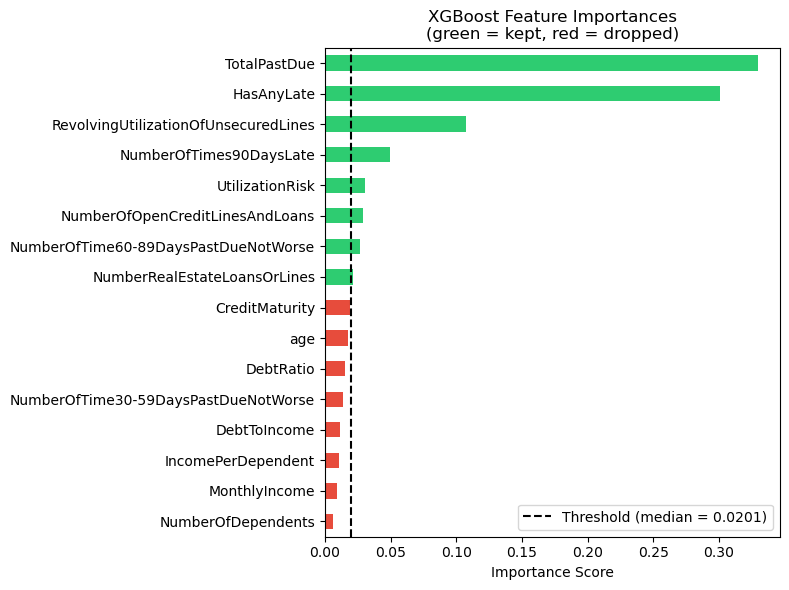

Saved → reports/feature_importance.png


In [51]:
from sklearn.feature_selection import SelectFromModel

# Train a quick XGBoost on engineered data to get importances
xgb_for_selection = XGBClassifier(
    **search.best_params_,          # use the tuned params we already found
    eval_metric      = "logloss",
    scale_pos_weight = scale_pos_weight,
    random_state     = 42,
    verbosity        = 0,
)
xgb_for_selection.fit(X_train_final, y_train)

# Select features with importance >= median importance
# Note: do NOT use prefit=True — fit the selector directly so estimator_ is set
selector = SelectFromModel(xgb_for_selection, threshold="median")
selector.fit(X_train_final, y_train)   # this sets selector.estimator_ correctly

X_train_selected = selector.transform(X_train_final)
X_test_selected  = selector.transform(X_test_final)

selected_features = X_train_final.columns[selector.get_support()].tolist()
dropped_features  = X_train_final.columns[~selector.get_support()].tolist()

print(f"Features selected : {len(selected_features)}/{X_train_final.shape[1]}")
print(f"\nKEPT  : {selected_features}")
print(f"DROPPED: {dropped_features}")

# Feature importance plot
importances = pd.Series(
    xgb_for_selection.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=True)

# Compute threshold manually (median of importances) for the plot label
importance_threshold = float(np.median(xgb_for_selection.feature_importances_))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2ecc71" if f in selected_features else "#e74c3c"
          for f in importances.index]
importances.plot(kind="barh", ax=ax, color=colors)
ax.axvline(importance_threshold, color="black", linestyle="--",
           label=f"Threshold (median = {importance_threshold:.4f})")
ax.set_title("XGBoost Feature Importances\n(green = kept, red = dropped)")
ax.set_xlabel("Importance Score")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/feature_importance.png", dpi=150)
plt.show()
print("Saved → reports/feature_importance.png")

## Cell 17 — Retrain Tuned XGBoost on Refined Features

Retrain the tuned XGBoost on the final engineered + selected feature set and compare against the previous best result.

In [54]:
# Retrain with best params on refined feature set
xgb_refined = XGBClassifier(
    **search.best_params_,
    eval_metric      = "logloss",
    scale_pos_weight = scale_pos_weight,
    random_state     = 42,
    verbosity        = 0,
)
xgb_refined.fit(X_train_selected, y_train)

y_pred_refined = xgb_refined.predict(X_test_selected)
y_prob_refined = xgb_refined.predict_proba(X_test_selected)[:, 1]

xgb_refined_metrics = get_metrics("XGBoost (refined)", y_test,
                                   y_pred_refined, y_prob_refined)
results.append(xgb_refined_metrics)

print("--- XGBoost (Refined: tuned + engineered features + selection) ---")
for k, v in xgb_refined_metrics.items():
    if k != "Model":
        print(f"  {k:<12}: {float(v):.4f}")

# Full progression table
print("\n===== Full Model Progression =====")
prog = pd.DataFrame(results).set_index("Model")
print(prog.to_string())

# Delta from tuned to refined
delta = prog.loc["XGBoost (refined)"] - prog.loc["XGBoost (tuned)"]
print("\nDelta (refined − tuned):")
for metric, diff in delta.items():
    symbol = "+" if diff >= 0 else ""
    print(f"  {metric:<12}: {symbol}{float(diff):.4f}")

# ── Decision: pick the best model ────────────────────────────────────────────
tuned_auc   = prog.loc["XGBoost (tuned)",   "ROC-AUC"]
refined_auc = prog.loc["XGBoost (refined)", "ROC-AUC"]

if refined_auc > tuned_auc:
    best_final_model    = xgb_refined
    best_final_pred     = y_pred_refined
    best_final_prob     = y_prob_refined
    best_final_name     = "XGBoost (refined)"
    use_feature_eng     = True
    print(f"\n✅ WINNER: Refined model (AUC {refined_auc:.4f} > {tuned_auc:.4f})")
else:
    best_final_model    = best_xgb
    best_final_pred     = y_pred_xgb_tuned
    best_final_prob     = y_prob_xgb_tuned
    best_final_name     = "XGBoost (tuned)"
    use_feature_eng     = False
    print(f"\n✅ WINNER: Tuned model (AUC {tuned_auc:.4f} >= {refined_auc:.4f})")
    print("   Feature engineering did not improve over tuned model.")
    print("   Saving tuned model as final — engineering steps kept for report.")

# Save updated comparison
prog.to_csv(f"{REPORTS_DIR}/model_comparison.csv")
print("\nUpdated comparison saved → reports/model_comparison.csv")

--- XGBoost (Refined: tuned + engineered features + selection) ---
  Accuracy    : 0.7961
  Precision   : 0.2205
  Recall      : 0.7635
  F1-Score    : 0.3422
  ROC-AUC     : 0.8567

===== Full Model Progression =====
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7958     0.2188  0.7540    0.3391   0.8548
Random Forest          0.9311     0.5142  0.1400    0.2200   0.8238
XGBoost (baseline)     0.8261     0.2410  0.6992    0.3585   0.8440
XGBoost (tuned)        0.7889     0.2197  0.7987    0.3446   0.8642
XGBoost (refined)      0.7961     0.2205  0.7635    0.3422   0.8567

Delta (refined − tuned):
  Accuracy    : +0.0072
  Precision   : +0.0008
  Recall      : -0.0352
  F1-Score    : -0.0024
  ROC-AUC     : -0.0075

✅ WINNER: Tuned model (AUC 0.8642 >= 0.8567)
   Feature engineering did not improve over tuned model.
   Saving tuned model as final — engineering steps kept f

## Cell 18 — Decision Threshold Optimisation

By default, `predict()` uses a 0.5 threshold. Since our dataset is imbalanced and we care about Recall (not missing eligible applicants), we can find the threshold that maximises F1-score — balancing Precision and Recall better than the default.

Default threshold (0.5) F1 : 0.3422
Optimal threshold          : 0.7808
Optimal threshold F1       : 0.4360

--- XGBoost (Refined + Optimal Threshold) ---
  Accuracy    : 0.9136
  Precision   : 0.3989
  Recall      : 0.4806
  F1-Score    : 0.4360
  ROC-AUC     : 0.8567


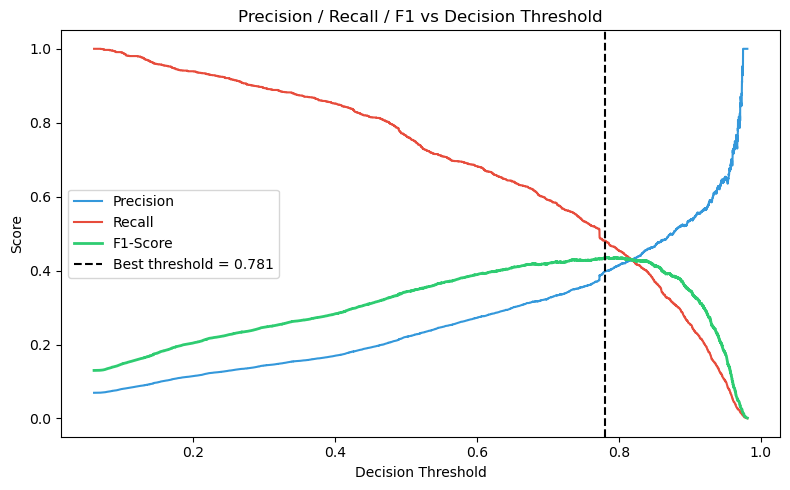

Saved → reports/threshold_curve.png


In [59]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_refined)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx       = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Default threshold (0.5) F1 : {f1_score(y_test, y_pred_refined):.4f}")
print(f"Optimal threshold          : {best_threshold:.4f}")
print(f"Optimal threshold F1       : {best_f1:.4f}")

# Apply optimal threshold
y_pred_thresh = (y_prob_refined >= best_threshold).astype(int)
thresh_metrics = get_metrics("XGBoost (refined + threshold)",
                              y_test, y_pred_thresh, y_prob_refined)
results.append(thresh_metrics)

print("\n--- XGBoost (Refined + Optimal Threshold) ---")
for k, v in thresh_metrics.items():
    if k != "Model":
        print(f"  {k:<12}: {float(v):.4f}")

# Precision-Recall curve plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="#3498db")
plt.plot(thresholds, recalls[:-1],    label="Recall",    color="#e74c3c")
plt.plot(thresholds, f1_scores[:-1],  label="F1-Score",  color="#2ecc71", linewidth=2)
plt.axvline(best_threshold, color="black", linestyle="--",
            label=f"Best threshold = {best_threshold:.3f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Decision Threshold")
plt.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/threshold_curve.png", dpi=150)
plt.show()
print("Saved → reports/threshold_curve.png")

## Cell 19 — Save Final Refined Model

In [62]:
import json

# ── Save the BEST performing model (auto-selected in Cell 17) ─────────────────
joblib.dump(best_final_model, f"{MODELS_DIR}/xgb_baseline.pkl")
print(f"Final model ({best_final_name}) saved → {MODELS_DIR}/xgb_baseline.pkl")

# Save best params + optimal threshold + which pipeline was used
final_params = {
    **search.best_params_,
    "optimal_threshold": float(best_threshold),
    "feature_engineering_used": use_feature_eng,
}
with open(f"{MODELS_DIR}/xgb_best_params.json", "w") as f:
    json.dump(final_params, f, indent=2)
print(f"Best params saved → {MODELS_DIR}/xgb_best_params.json")

# Save outlier caps (Person 4 needs these for Streamlit input preprocessing)
with open(f"{MODELS_DIR}/outlier_caps.json", "w") as f:
    json.dump({k: float(v) for k, v in caps.items()}, f, indent=2)
print(f"Outlier caps saved → {MODELS_DIR}/outlier_caps.json")

# NOTE: feature_selector.pkl is NOT saved — tuned model uses original features
# Person 4 only needs: xgb_baseline.pkl, outlier_caps.json, scaler.pkl (Person 1)

# Final summary
print("\n" + "="*60)
print(f"FINAL MODEL: {best_final_name}")
print("="*60)
final_df = pd.DataFrame(results).set_index("Model")
print(final_df.to_string())
final_df.to_csv(f"{REPORTS_DIR}/model_comparison.csv")

# Reload and verify
reloaded = joblib.load(f"{MODELS_DIR}/xgb_baseline.pkl")
verify = reloaded.predict(X_test[:5] if not use_feature_eng else X_test_selected[:5])
print(f"\nVerification (first 5 predictions): {verify}")
print("Model reload OK — ready to hand off to Person 3.")

Final model (XGBoost (tuned)) saved → ../models/xgb_baseline.pkl
Best params saved → ../models/xgb_best_params.json
Outlier caps saved → ../models/outlier_caps.json

FINAL MODEL: XGBoost (tuned)
                               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                        
Logistic Regression              0.7958     0.2188  0.7540    0.3391   0.8548
Random Forest                    0.9311     0.5142  0.1400    0.2200   0.8238
XGBoost (baseline)               0.8261     0.2410  0.6992    0.3585   0.8440
XGBoost (tuned)                  0.7889     0.2197  0.7987    0.3446   0.8642
XGBoost (refined)                0.7961     0.2205  0.7635    0.3422   0.8567
XGBoost (refined + threshold)    0.9136     0.3989  0.4806    0.4360   0.8567
XGBoost (refined + threshold)    0.9136     0.3989  0.4806    0.4360   0.8567

Verification (first 5 predictions): [0 0 0 0 0]
Model reload OK — ready to hand off to Person 3.


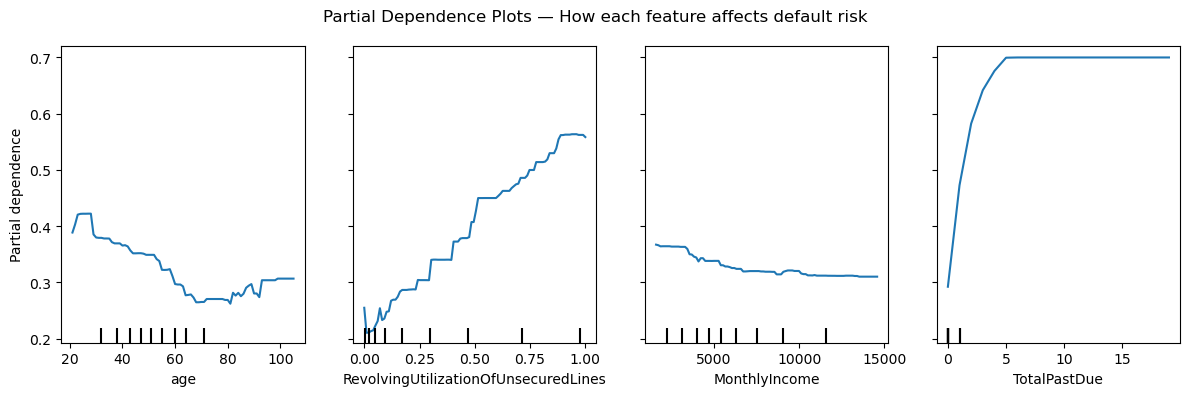

In [64]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    best_xgb, X_train,
    features=["age", "RevolvingUtilizationOfUnsecuredLines",
              "MonthlyIncome", "TotalPastDue"],
    ax=ax, n_cols=4
)
plt.suptitle("Partial Dependence Plots — How each feature affects default risk")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/partial_dependence_plots.png", dpi=150)
plt.show()